In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("dataset.csv", sep=";")

# Limpiar columnas
df.columns = df.columns.str.strip()

# Fechas
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

# Crear FechaHora
df["FechaHora"] = pd.to_datetime(
    df["Fecha"].astype(str) + " " + df["Hora"].astype(str),
    errors="coerce"
)

# Columnas numéricas
cols_num = [
    "PM1","PM2.5","PM10","NO","NO2","NOx","O3","SO2","CO",
    "Velocidad del viento","Direccion del viento","NH3",
    "C7H8","C6H6","Ruido","C8H10","Temperatura",
    "Humedad relativa","Presion","Radiacion",
    "Precipitacion","Velocidad maxima del viento"
]

for col in cols_num:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

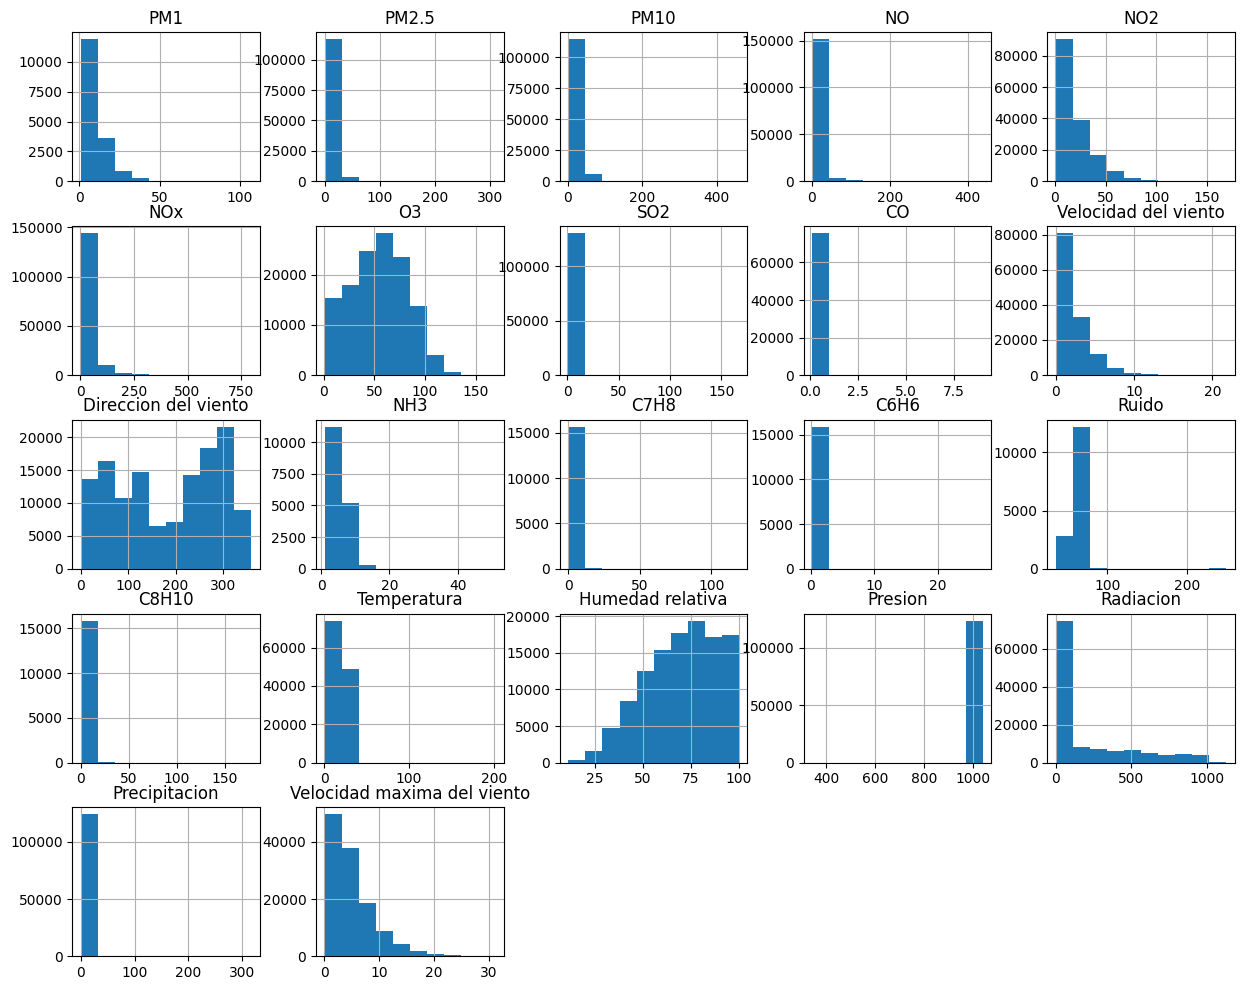

In [45]:
df[cols_num].hist(figsize=(15,12))
plt.show()

In [46]:
df["Fecha"] = pd.to_datetime(df["Fecha"], errors="coerce")

df["FechaHora"] = pd.to_datetime(
    df["Fecha"].astype(str) + " " + df["Hora"].astype(str),
    format="mixed",
    errors="coerce"
)

df["Hora_num"] = df["FechaHora"].dt.hour

In [47]:
df.isnull().sum()

Id                                  0
Fecha                               0
Dia de la semana                    0
Dia del mes                         0
Hora                                0
Estacion                            0
PM1                            184728
PM2.5                           80811
PM10                            80816
NO                              44767
NO2                             44770
NOx                             44768
O3                              73281
SO2                             70764
CO                             125821
Velocidad del viento            70132
Direccion del viento            69237
NH3                            184796
C7H8                           185662
C6H6                           185583
Ruido                          186393
C8H10                          185592
Temperatura                     78758
Humedad relativa                86911
Presion                         78028
Radiacion                       79960
Precipitacio

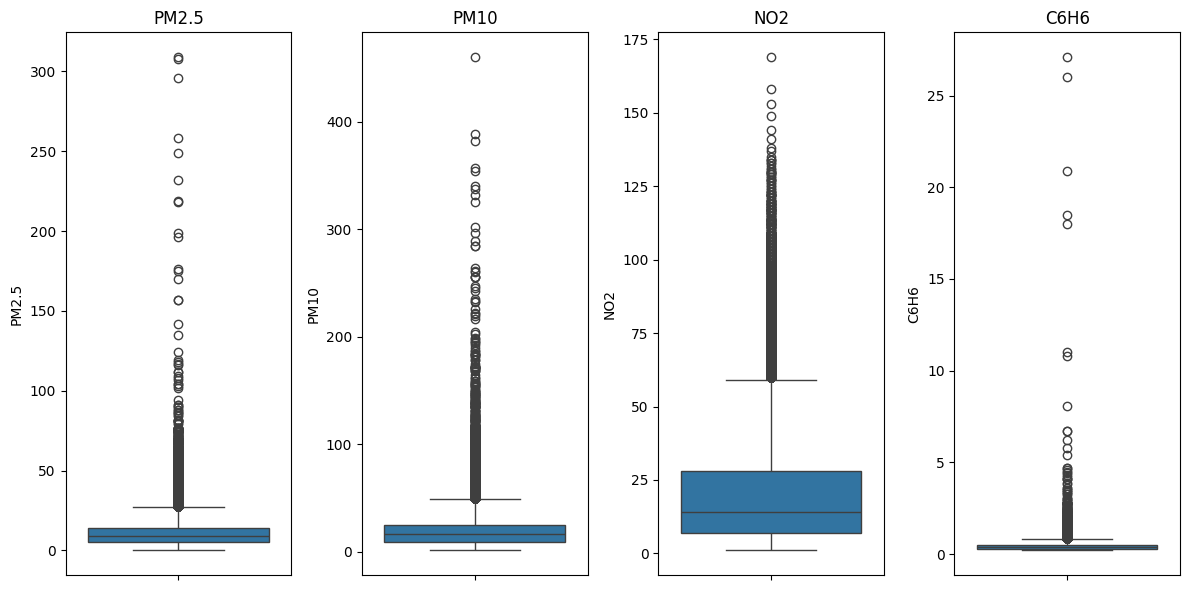

In [48]:
variables = ["PM2.5","PM10","NO2","C6H6"]

plt.figure(figsize=(12,6))

for i, var in enumerate(variables, 1):
    plt.subplot(1, 4, i)
    sns.boxplot(y=df[var])
    plt.title(var)

plt.tight_layout()
plt.show()

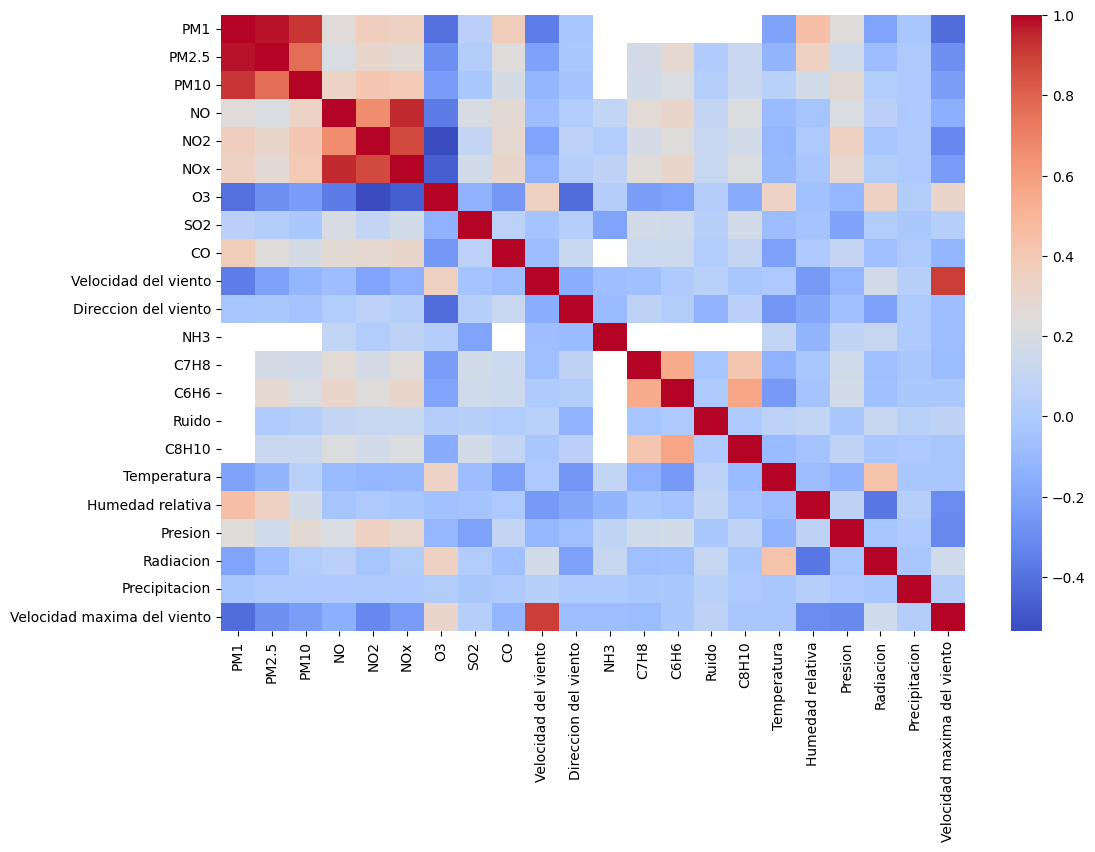

In [49]:
corr = df[cols_num].corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [50]:
df[df["Temperatura"] > 50]

,Id,Fecha,Dia de la semana,Dia del mes,Hora,Estacion,PM1,PM2.5,PM10,NO,...,Temperatura,Humedad relativa,Presion,Radiacion,Precipitacion,Velocidad maxima del viento,Fecha creacion,Fecha baja,FechaHora,Hora_num
80632,190427,2022-09-27,Martes,27,10:00,Puerto llit antic Turia,NaN,91.0,NaN,3.0,...,201.0,26.0,NaN,NaN,21.9,12.7,2023-02-15,NaN,2022-09-27 10:00:00,10


In [51]:
# Rango de fechas
df["Fecha"].min(), df["Fecha"].max()

(Timestamp('2021-01-01 00:00:00'), Timestamp('2022-12-31 00:00:00'))

In [52]:
#Huecos temporales
df.groupby("Estacion")["Hora"].count()

Estacion
Avda. Francia                17520
Bulevard Sud                 17520
Conselleria Meteo            17520
Moli del Sol                 17520
Nazaret Meteo                17520
Pista Silla                  17520
Politecnico                  17520
Puerto Moll Trans. Ponent    17520
Puerto llit antic Turia      17520
Valencia Centro              17520
Valencia Olivereta            8760
Viveros                      17520
Name: Hora, dtype: int64

In [53]:
# Contaminantes (solo los importantes)
contaminantes = ["PM1","PM2.5","PM10","NO","NO2","NOx","O3","SO2","CO","NH3","C7H8","C6H6","C8H10"]

# Estaciones que tienen datos en TODOS los contaminantes
estaciones_completas = df.groupby("Estacion")[contaminantes].apply(lambda x: x.notnull().all().all())

estaciones_completas

Estacion
Avda. Francia                False
Bulevard Sud                 False
Conselleria Meteo            False
Moli del Sol                 False
Nazaret Meteo                False
Pista Silla                  False
Politecnico                  False
Puerto Moll Trans. Ponent    False
Puerto llit antic Turia      False
Valencia Centro              False
Valencia Olivereta           False
Viveros                      False
dtype: bool

In [54]:
df.groupby("Estacion")[cols_num].count().mean(axis=1).sort_values(ascending=False)

Estacion
Pista Silla                  12076.136364
Puerto Moll Trans. Ponent    11817.545455
Moli del Sol                  9938.136364
Avda. Francia                 9932.318182
Puerto llit antic Turia       9069.772727
Politecnico                   8270.500000
Bulevard Sud                  7647.727273
Viveros                       7004.636364
Valencia Centro               6935.181818
Conselleria Meteo             6224.818182
Nazaret Meteo                 6150.590909
Valencia Olivereta            1981.363636
dtype: float64

In [55]:
#Estacion con mayor NO2
df.groupby("Estacion")["NO2"].mean().sort_values(ascending=False)

Estacion
Valencia Olivereta           36.990708
Puerto llit antic Turia      27.976891
Puerto Moll Trans. Ponent    27.348059
Bulevard Sud                 22.769226
Pista Silla                  20.304936
Valencia Centro              18.335936
Viveros                      16.819180
Moli del Sol                 14.976751
Avda. Francia                12.435654
Politecnico                  10.516865
Conselleria Meteo                  NaN
Nazaret Meteo                      NaN
Name: NO2, dtype: float64

In [56]:
# Contaminante con mayor variabilidad
df.groupby("Estacion")[cols_num].mean().std().sort_values(ascending=False)

NOx                            15.249640
Direccion del viento           13.807313
NO2                             8.111434
Presion                         5.880371
Radiacion                       5.442746
PM10                            5.075221
NO                              4.727625
O3                              2.659247
PM2.5                           1.696110
Humedad relativa                1.281898
Velocidad maxima del viento     0.858336
Temperatura                     0.826678
SO2                             0.574634
Velocidad del viento            0.149996
CO                              0.020542
Precipitacion                   0.014370
PM1                                  NaN
NH3                                  NaN
C7H8                                 NaN
C6H6                                 NaN
Ruido                                NaN
C8H10                                NaN
dtype: float64